In [1]:
import pandas as pd
import numpy as np

df=pd.read_csv('googleplaystore.csv')
print("shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

shape: (10841, 13)

Columns: ['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.00.00,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.00.00,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.02.04,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [8]:

df = pd.read_csv('googleplaystore.csv')

df = df.drop_duplicates(subset='App')
print("shape after dropping duplicates:", df.shape)
df = df[df['Category'] != '1.9']
df = df.dropna(subset=['Rating'])
df['Installs'] = df['Installs'].astype(str).str.replace('+', '').str.replace(',', '')
df['Installs'] = df['Installs'].replace('Free', '0')
df['Installs'] = df['Installs'].astype(int)

df['Price'] = df['Price'].astype(str).str.replace('$', '')
df['Price'] = df['Price'].astype(float)

def convert_size(size):
    size = str(size)
    if 'M' in size:
        return float(size.replace('M', ''))
    elif 'k' in size:
        return float(size.replace('k', '')) / 1024
    else:
        return np.nan
df['Size'] = df['Size'].apply(convert_size)
df['Reviews'] = df['Reviews'].astype(int)
print("shape after cleaning:", df.shape)
print("\nData types after cleaning:")
print(df.info())


shape after dropping duplicates: (9660, 13)
shape after cleaning: (8196, 13)

Data types after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 8196 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             8196 non-null   object 
 1   Category        8196 non-null   object 
 2   Rating          8196 non-null   float64
 3   Reviews         8196 non-null   int64  
 4   Size            7027 non-null   float64
 5   Installs        8196 non-null   int64  
 6   Type            8196 non-null   object 
 7   Price           8196 non-null   float64
 8   Content Rating  8196 non-null   object 
 9   Genres          8196 non-null   object 
 10  Last Updated    8196 non-null   object 
 11  Current Ver     8192 non-null   object 
 12  Android Ver     8194 non-null   object 
dtypes: float64(3), int64(2), object(8)
memory usage: 896.4+ KB
None


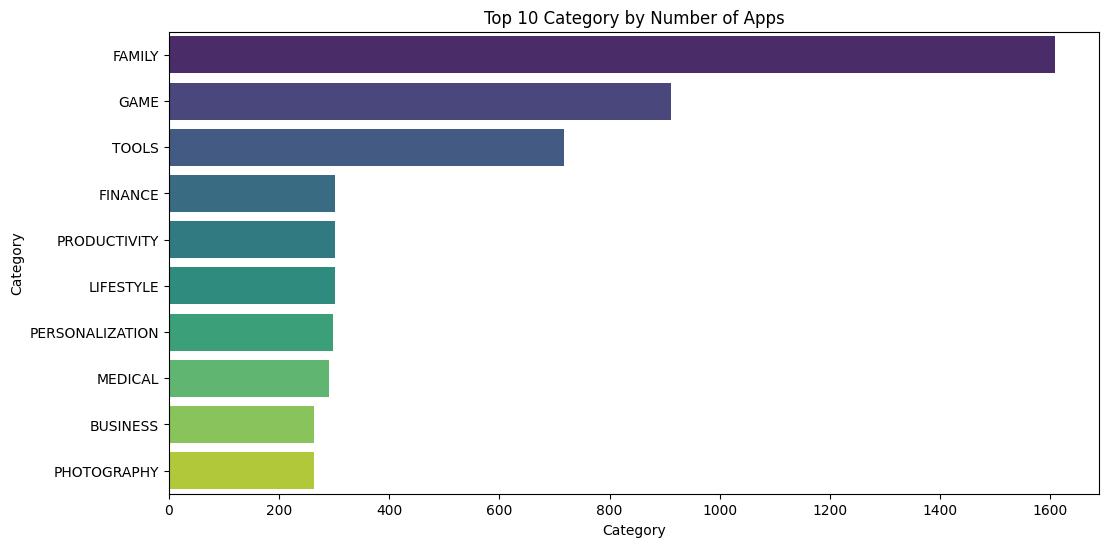

Insight:FAMILY and GAME are the most popular categories in the Google Play Store


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
top_cat=df['Category'].value_counts().head(10)
sns.barplot(x=top_cat.values, y=top_cat.index,hue=top_cat.index, palette='viridis', legend=False)
plt.title('Top 10 Category by Number of Apps')
plt.xlabel('Category')
plt.ylabel('Number of Apps')
plt.ylabel('Category')
plt.show()
print("Insight:FAMILY and GAME are the most popular categories in the Google Play Store")



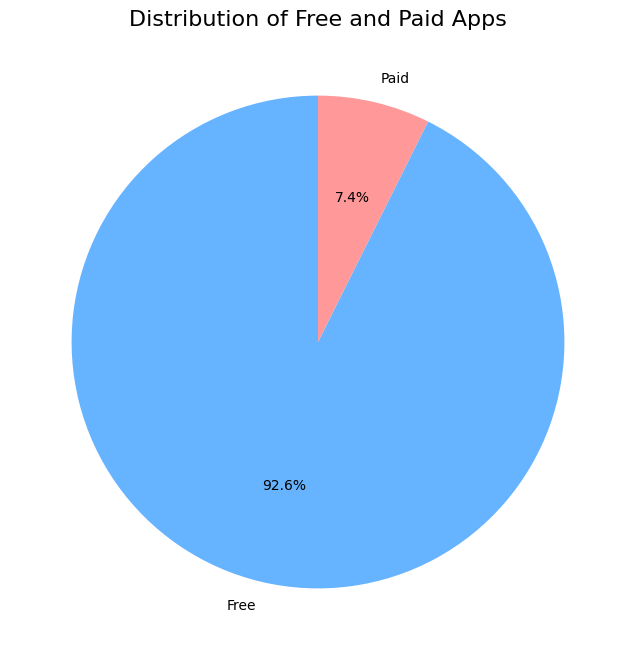

Insight: 92.6% of apps are free


In [17]:

plt.figure(figsize=(8,8))
types = df['Type'].value_counts()
plt.pie(types, labels=types.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
plt.title('Distribution of Free and Paid Apps', fontsize=16)
plt.show()
print(f"Insight: {df['Type'].value_counts(normalize=True)['Free']*100:.1f}% of apps are free")

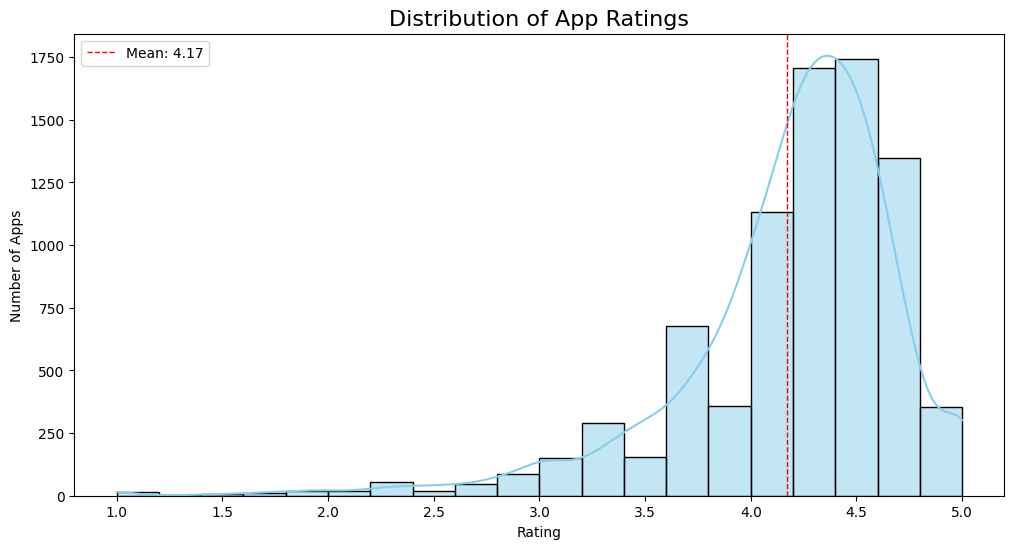

Insight: The average rating of apps is 4.17, with most apps having ratings between 4 and 5.


In [18]:
plt.figure(figsize=(12, 6))
sns.histplot(df['Rating'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of App Ratings', fontsize=16)
plt.xlabel('Rating')
plt.ylabel('Number of Apps')
plt.axvline(df['Rating'].mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {df["Rating"].mean():.2f}')
plt.legend()
plt.show()
print(f"Insight: The average rating of apps is {df['Rating'].mean():.2f}, with most apps having ratings between 4 and 5.")

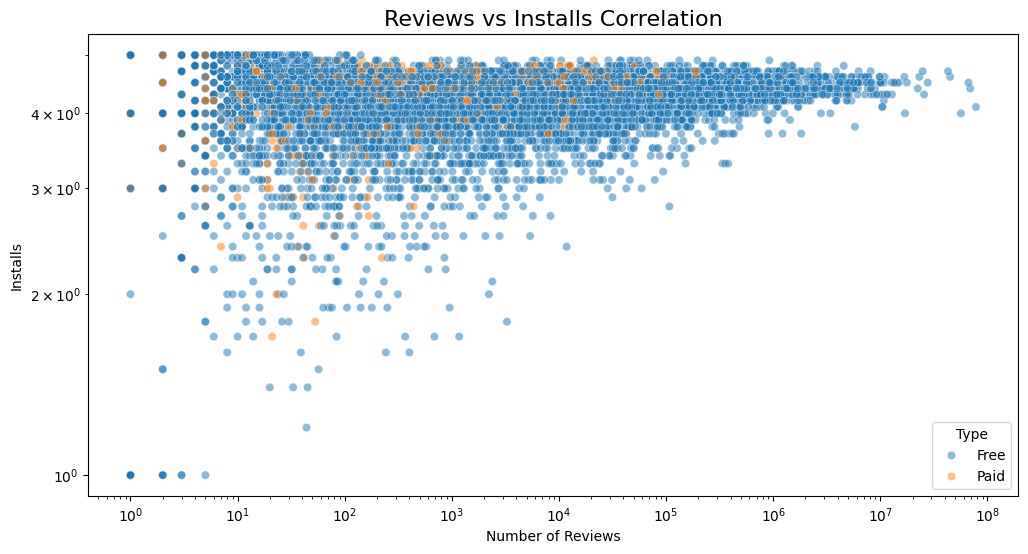

Insight: Apps with more reviews generally have more installs, indicating a positive correlation between reviews and installs.


In [19]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Reviews', y='Rating', data=df, alpha=0.5,hue='Type')
plt.title('Reviews vs Installs Correlation', fontsize=16)
plt.xlabel('Number of Reviews')
plt.ylabel('Installs')
plt.xscale('log')
plt.yscale('log')
plt.show()
print("Insight: Apps with more reviews generally have more installs, indicating a positive correlation between reviews and installs.")

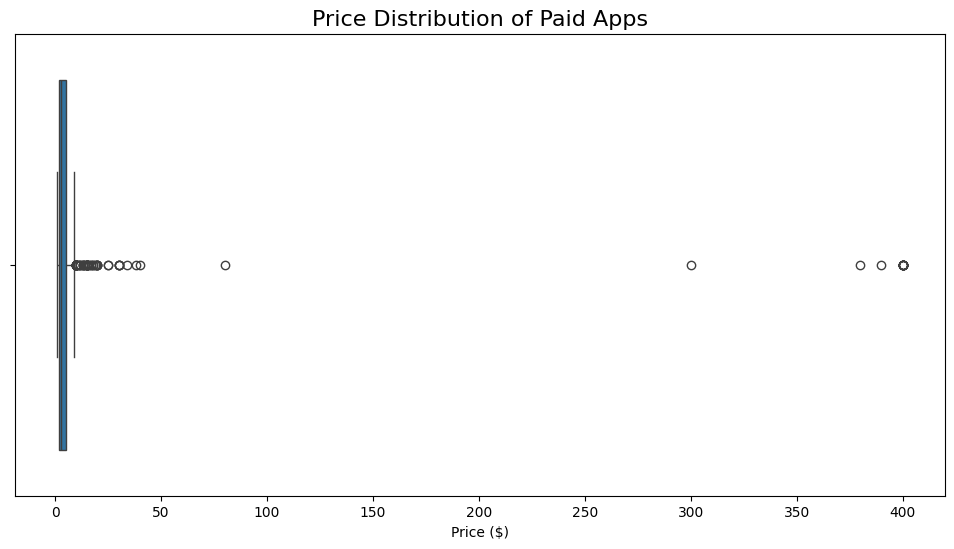

Insight: 75% of paid apps are priced below $5, Outliers $400 also exist


In [20]:
plt.figure(figsize=(12, 6))
paid_apps = df[df['Type'] == 'Paid']
sns.boxplot(x=paid_apps['Price'])
plt.title('Price Distribution of Paid Apps', fontsize=16)
plt.xlabel('Price ($)')
plt.show()

print(f"Insight: 75% of paid apps are priced below $5, Outliers $400 also exist")